# Sports League Optimization

### 1. Imports

In [ ]:
# Imports principais
import random
import numpy as np
import pandas as pd

# Imports da tua própria biblioteca
from library.classes import *
from library.crossover import *  # importa operadores de crossover que criaste
from library.fixed_para import *  # importa as constantes como POSITIONS, TEAM_SIZE, etc.
from library.mutation import *  # importa operadores de mutação
from library.selection import *  # importa mecanismos de seleção



[INFO] Dataset carregado com sucesso de: C:\Users\rodri\Desktop\Nova IMS\1ano\2nd Semester\Computational Intelligence for Otimization\CIFO2025\data\players(in).csv


### 2. Analysing a random Solution

In [7]:
sol = FootballSolution()

In [8]:
# Ver cada equipa
for i, team in enumerate(sol.repr):
    print(f"\n--- Team {i+1} ---")
    print(team)



--- Team 1 ---
Blake Henderson - GK - Skill: 87 - Salary: 95M
Lucas Bennett - DEF - Skill: 85 - Salary: 90M
Ethan Howard - DEF - Skill: 80 - Salary: 70M
Nathan Wright - MID - Skill: 92 - Salary: 120M
Austin Torres - MID - Skill: 82 - Salary: 80M
Landon Powell - FWD - Skill: 89 - Salary: 110M
Zachary Nelson - FWD - Skill: 86 - Salary: 92M

--- Team 2 ---
Alex Carter - GK - Skill: 85 - Salary: 90M
Maxwell Flores - DEF - Skill: 81 - Salary: 72M
Logan Brooks - DEF - Skill: 86 - Salary: 95M
Spencer Ward - MID - Skill: 84 - Salary: 85M
Hunter Cooper - MID - Skill: 83 - Salary: 85M
Sebastian Perry - FWD - Skill: 95 - Salary: 150M
Tyler Jenkins - FWD - Skill: 80 - Salary: 70M

--- Team 3 ---
Jordan Smith - GK - Skill: 88 - Salary: 100M
Caleb Fisher - DEF - Skill: 84 - Salary: 85M
Daniel Foster - DEF - Skill: 90 - Salary: 110M
Dylan Morgan - MID - Skill: 91 - Salary: 115M
Bentley Rivera - MID - Skill: 88 - Salary: 100M
Chase Murphy - FWD - Skill: 86 - Salary: 95M
Adrian Collins - FWD - Skill: 

In [9]:
print("Fitness:", sol.fitness())

Fitness: 0.5164379299855917


In [10]:
print(sol)


[Team(avg_skill=85.86, valid=True), Team(avg_skill=84.86, valid=True), Team(avg_skill=87.43, valid=True), Team(avg_skill=86.71, valid=True), Team(avg_skill=87.14, valid=True)]


### 3. Creating a random initial Population

Criar e analisar uma população inicial:

Estatísticas básicas do fitness

Histograma da distribuição

Visualização de uma solução aleatória

In [12]:
population = [FootballSolution() for _ in range(50)]
population

[[Team(avg_skill=86.29, valid=True), Team(avg_skill=84.86, valid=True), Team(avg_skill=87.71, valid=True), Team(avg_skill=85.29, valid=True), Team(avg_skill=87.86, valid=True)],
 [Team(avg_skill=87.14, valid=True), Team(avg_skill=86.29, valid=True), Team(avg_skill=86.43, valid=True), Team(avg_skill=84.29, valid=True), Team(avg_skill=87.86, valid=True)],
 [Team(avg_skill=87.71, valid=True), Team(avg_skill=86.29, valid=True), Team(avg_skill=86.57, valid=True), Team(avg_skill=84.57, valid=True), Team(avg_skill=86.86, valid=True)],
 [Team(avg_skill=85.29, valid=True), Team(avg_skill=87.14, valid=True), Team(avg_skill=85.29, valid=True), Team(avg_skill=88.00, valid=True), Team(avg_skill=86.29, valid=True)],
 [Team(avg_skill=86.57, valid=True), Team(avg_skill=86.57, valid=True), Team(avg_skill=86.00, valid=True), Team(avg_skill=87.43, valid=True), Team(avg_skill=85.43, valid=True)],
 [Team(avg_skill=88.00, valid=True), Team(avg_skill=85.29, valid=True), Team(avg_skill=87.71, valid=True), Tea

In [13]:
fitness_values = [ind.fitness() for ind in population]


In [14]:
print(f"Fitness médio: {np.mean(fitness_values):.4f}")
print(f"Fitness mínimo: {np.min(fitness_values):.4f}")
print(f"Fitness máximo: {np.max(fitness_values):.4f}")
print(f"Desvio padrão: {np.std(fitness_values):.4f}")


Fitness médio: 0.5023
Fitness mínimo: 0.3435
Fitness máximo: 0.6830
Desvio padrão: 0.0756


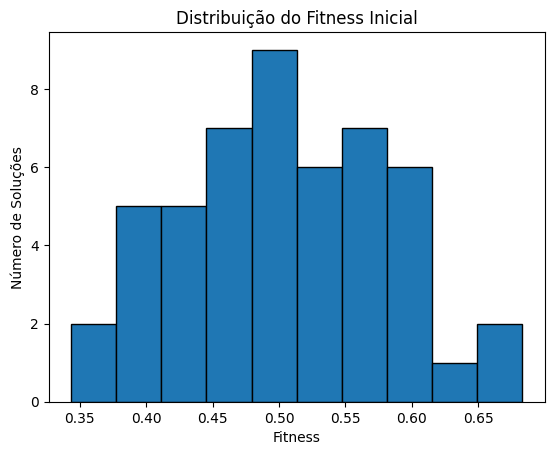

In [15]:
import matplotlib.pyplot as plt

plt.hist(fitness_values, bins=10, edgecolor='black')
plt.title("Distribuição do Fitness Inicial")
plt.xlabel("Fitness")
plt.ylabel("Número de Soluções")
plt.show()


### 4. Making 1 generation to see if there are improvements

Aplicar seleção, crossover e mutação para gerar uma nova população

Comparar antes/depois (fitness médio, máximo, gráfico)

Confirmar que os operadores funcionam

In [16]:
new_population = []

# Elitismo opcional
elitism = True
if elitism:
    elite = max(population, key=lambda ind: ind.fitness())
    new_population.append(deepcopy(elite))

while len(new_population) < len(population):
    # Selecionar dois pais
    p1 = tournament_selection(population)
    p2 = tournament_selection(population)

    # Cruzamento
    c1, c2 = team_swap_crossover(None, p1, p2)

    # Mutação
    c1 = mutate_swap_between_teams(None, c1)
    c2 = mutate_swap_between_teams(None, c2)

    # Adicionar à nova população
    for child in [c1, c2]:
        if len(new_population) < len(population):
            new_population.append(child)


In [17]:
new_fitness = [ind.fitness() for ind in new_population]

print("ANTES:")
print(f"  Média: {np.mean(fitness_values):.4f} | Máx: {np.max(fitness_values):.4f}")

print("DEPOIS:")
print(f"  Média: {np.mean(new_fitness):.4f} | Máx: {np.max(new_fitness):.4f}")


ANTES:
  Média: 0.5023 | Máx: 0.6830
DEPOIS:
  Média: 0.6171 | Máx: 0.8239


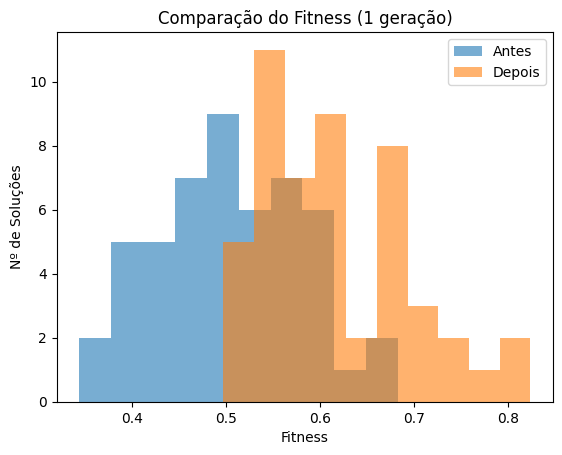

In [18]:
plt.hist(fitness_values, bins=10, alpha=0.6, label="Antes")
plt.hist(new_fitness, bins=10, alpha=0.6, label="Depois")
plt.title("Comparação do Fitness (1 geração)")
plt.xlabel("Fitness")
plt.ylabel("Nº de Soluções")
plt.legend()
plt.show()


### 5. Generations Loop with fixed setup

Executar várias gerações (ex: 30 ou 100) com um conjunto fixo de operadores

Guardar o melhor fitness por geração

Gráfico da evolução do fitness

In [35]:
generations = 50
pop_size = 50
elitism = True

population = [FootballSolution() for _ in range(pop_size)]
best_fitness_per_gen = []


In [36]:
for gen in range(generations):
    new_population = []

    if elitism:
        elite = max(population, key=lambda ind: ind.fitness())
        new_population.append(deepcopy(elite))

    while len(new_population) < pop_size:
        p1 = tournament_selection(population)
        p2 = tournament_selection(population)

        c1, c2 = team_swap_crossover(None, p1, p2)

        c1 = mutate_swap_between_teams(None, c1)
        c2 = mutate_swap_between_teams(None, c2)

        for child in [c1, c2]:
            if len(new_population) < pop_size:
                new_population.append(child)

    population = new_population

    best_fitness = max(ind.fitness() for ind in population)
    best_fitness_per_gen.append(best_fitness)
    print(f"Geração {gen+1}: Melhor fitness = {best_fitness:.4f}")


Geração 1: Melhor fitness = 0.8647
Geração 2: Melhor fitness = 0.8647
Geração 3: Melhor fitness = 0.8772
Geração 4: Melhor fitness = 0.8772
Geração 5: Melhor fitness = 0.8772
Geração 6: Melhor fitness = 0.8772
Geração 7: Melhor fitness = 0.8772
Geração 8: Melhor fitness = 0.8772
Geração 9: Melhor fitness = 0.8772
Geração 10: Melhor fitness = 0.8772
Geração 11: Melhor fitness = 0.8772
Geração 12: Melhor fitness = 0.8772
Geração 13: Melhor fitness = 0.8772
Geração 14: Melhor fitness = 0.8772
Geração 15: Melhor fitness = 0.8772
Geração 16: Melhor fitness = 0.8772
Geração 17: Melhor fitness = 0.8772
Geração 18: Melhor fitness = 0.8772
Geração 19: Melhor fitness = 0.8772
Geração 20: Melhor fitness = 0.8772
Geração 21: Melhor fitness = 0.8772
Geração 22: Melhor fitness = 0.8772
Geração 23: Melhor fitness = 0.8772
Geração 24: Melhor fitness = 0.8772
Geração 25: Melhor fitness = 0.8772
Geração 26: Melhor fitness = 0.8772
Geração 27: Melhor fitness = 0.8772
Geração 28: Melhor fitness = 0.8772
G

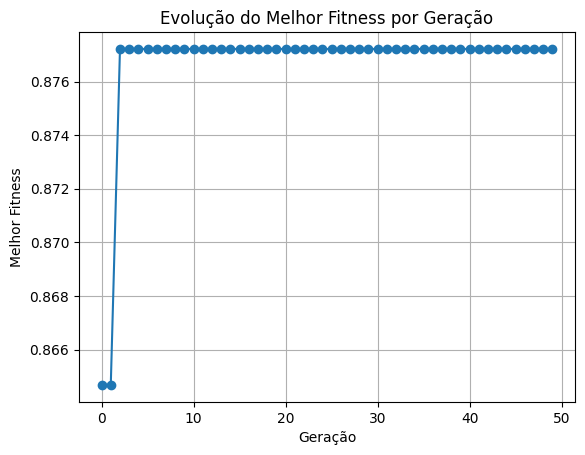

In [37]:
plt.plot(best_fitness_per_gen, marker='o')
plt.title("Evolução do Melhor Fitness por Geração")
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.grid(True)
plt.show()


### 6. The search for the best setup

Usar a função run_ga_test() para comparar várias combinações:

2 seleções × 2 crossovers × 3 mutações × 2 elitismos = 24 combinações

Guardar os resultados

Visualizar os melhores (tabela + gráfico)



In [1]:
from selection_analysis.best_selection import (
    run_ga_test,
    selection_methods,
    crossover_methods,
    mutation_methods
)

[INFO] Dataset carregado com sucesso de: C:\Users\rodri\Desktop\Nova IMS\1ano\2nd Semester\Computational Intelligence for Otimization\CIFO2025\data\players(in).csv

Running tournament|team_swap|global_perm|elitism=True ...


KeyboardInterrupt: 

In [27]:
results = []

for elitism_flag in [True, False]:
    for sel_name, sel_func in selection_methods.items():
        for cross_name, cross_func in crossover_methods.items():
            for mut_name, mut_func in mutation_methods.items():
                name = f"{sel_name}|{cross_name}|{mut_name}|elitism={elitism_flag}"
                print(f"\nRunning {name} ...")

                median_final, all_finals = run_ga_test(
                    selection_func=sel_func,
                    crossover_func=cross_func,
                    mutation_func=mut_func,
                    elitism=elitism_flag,
                    generations=30,
                    pop_size=20,
                    n_runs=15,
                    crossover_prob=0.9,
                    mutation_prob=0.1
                )

                results.append((name, median_final))



Running tournament|team_swap|global_perm|elitism=True ...

Running tournament|team_swap|random_swap|elitism=True ...

Running tournament|team_swap|between_teams|elitism=True ...

Running tournament|team_two_point|global_perm|elitism=True ...

Running tournament|team_two_point|random_swap|elitism=True ...

Running tournament|team_two_point|between_teams|elitism=True ...

Running fitness_proportionate|team_swap|global_perm|elitism=True ...

Running fitness_proportionate|team_swap|random_swap|elitism=True ...

Running fitness_proportionate|team_swap|between_teams|elitism=True ...

Running fitness_proportionate|team_two_point|global_perm|elitism=True ...

Running fitness_proportionate|team_two_point|random_swap|elitism=True ...

Running fitness_proportionate|team_two_point|between_teams|elitism=True ...

Running tournament|team_swap|global_perm|elitism=False ...

Running tournament|team_swap|random_swap|elitism=False ...

Running tournament|team_swap|between_teams|elitism=False ...

Runni

In [28]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["Combinação", "Median Fitness"])
df_results = df_results.sort_values(by="Median Fitness", ascending=False)

# Mostrar top 5
df_results.head()


,Combinação,Median Fitness
13,tournament|team_swap|random_swap|elitism=False,0.853659
7,fitness_proportionate|team_swap|random_swap|el...,0.840674
9,fitness_proportionate|team_two_point|global_pe...,0.840674
14,tournament|team_swap|between_teams|elitism=False,0.837675
8,fitness_proportionate|team_swap|between_teams|...,0.837675


C:\Users\rodri\AppData\Local\Temp\ipykernel_28892\1344406121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Median Fitness", y="Combinação", palette="viridis")


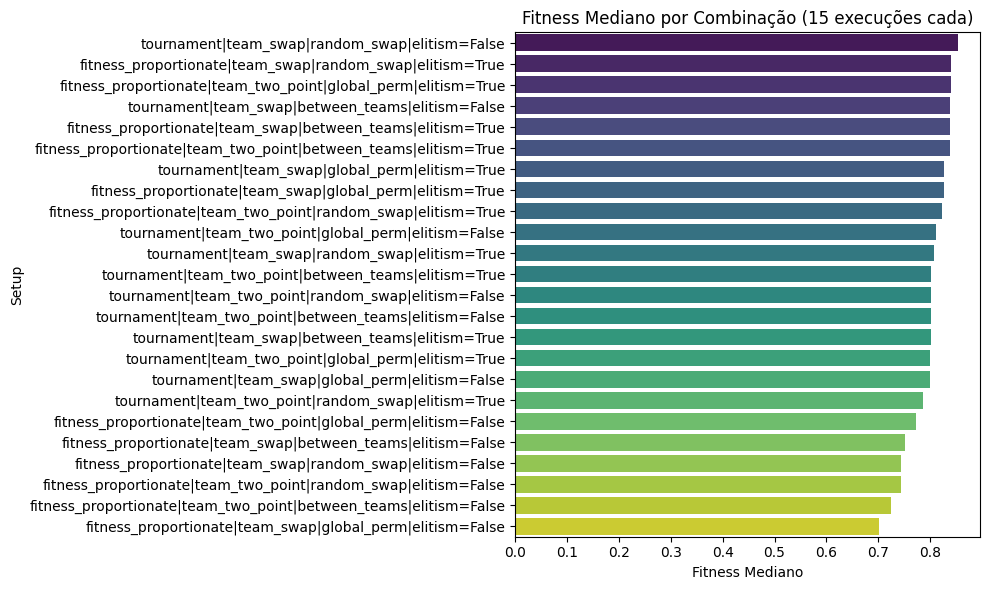

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="Median Fitness", y="Combinação", palette="viridis")
plt.title("Fitness Mediano por Combinação (15 execuções cada)")
plt.xlabel("Fitness Mediano")
plt.ylabel("Setup")
plt.tight_layout()
plt.show()


### 7. Analysis of the best setup

Escolher a melhor combinação

Executar uma corrida longa com n_runs=1 e generations=100

Mostrar:

Evolução do fitness

Exemplo de solução final (mostrar equipas)

Comparação da diversidade (desvio padrão dos skills)

In [38]:
def run_one_evolution(selection_func, crossover_func, mutation_func,
                      generations=100, pop_size=50, elitism=True,
                      crossover_prob=0.9, mutation_prob=0.1):
    
    from copy import deepcopy
    from library.classes import FootballSolution

    population = [FootballSolution() for _ in range(pop_size)]
    best_fitnesses = []
    best_solution = None

    for gen in range(generations):
        new_population = []

        if elitism:
            elite = deepcopy(max(population, key=lambda ind: ind.fitness()))
            new_population.append(elite)

        while len(new_population) < pop_size:
            p1 = selection_func(population)
            p2 = selection_func(population)

            if random.random() < crossover_prob:
                c1, c2 = crossover_func(None, p1, p2)
            else:
                c1, c2 = deepcopy(p1), deepcopy(p2)

            if random.random() < mutation_prob:
                c1 = mutation_func(None, c1)
            if random.random() < mutation_prob:
                c2 = mutation_func(None, c2)

            for child in [c1, c2]:
                if len(new_population) < pop_size:
                    new_population.append(child)

        population = new_population

        best = max(population, key=lambda ind: ind.fitness())
        best_fitnesses.append(best.fitness())
        best_solution = deepcopy(best)

    return best_fitnesses, best_solution


In [39]:
# Importa os operadores específicos
from library.selection import tournament_selection, fitness_proportionate_selection
from library.crossover import team_swap_crossover, team_two_point_crossover
from library.mutation import mutate_random_position_swap, mutate_global_position_permutation

# Setup 1
fitnesses_1, best_sol_1 = run_one_evolution(
    tournament_selection,
    team_swap_crossover,
    mutate_random_position_swap,
    elitism=False
)

# Setup 2
fitnesses_2, best_sol_2 = run_one_evolution(
    fitness_proportionate_selection,
    team_swap_crossover,
    mutate_random_position_swap,
    elitism=True
)

# Setup 3
fitnesses_3, best_sol_3 = run_one_evolution(
    fitness_proportionate_selection,
    team_two_point_crossover,
    mutate_global_position_permutation,
    elitism=True
)


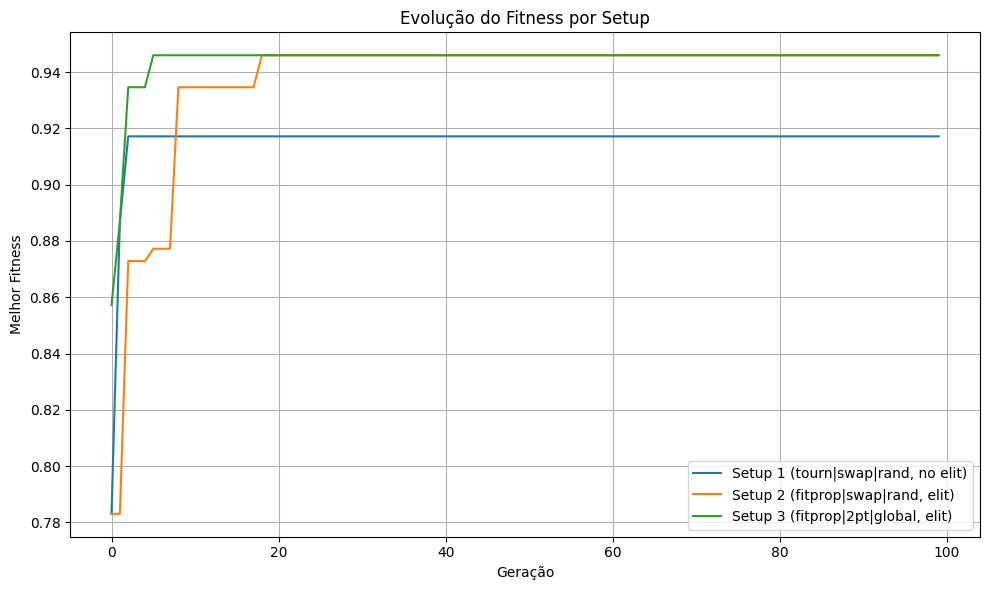

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(fitnesses_1, label="Setup 1 (tourn|swap|rand, no elit)")
plt.plot(fitnesses_2, label="Setup 2 (fitprop|swap|rand, elit)")
plt.plot(fitnesses_3, label="Setup 3 (fitprop|2pt|global, elit)")
plt.title("Evolução do Fitness por Setup")
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
print(f"Fitness final: {fitnesses_1[-1]:.4f}")

Fitness final: 0.9171


In [42]:
for i, team in enumerate(best_sol_1.repr):
    print(f"\n--- Equipa {i+1} ---")
    print(team)



--- Equipa 1 ---
Alex Carter - GK - Skill: 85 - Salary: 90M
Jaxon Griffin - DEF - Skill: 79 - Salary: 65M
Lucas Bennett - DEF - Skill: 85 - Salary: 90M
Dominic Bell - MID - Skill: 86 - Salary: 95M
Dylan Morgan - MID - Skill: 91 - Salary: 115M
Julian Scott - FWD - Skill: 92 - Salary: 130M
Zachary Nelson - FWD - Skill: 86 - Salary: 92M

--- Equipa 2 ---
Blake Henderson - GK - Skill: 87 - Salary: 95M
Owen Parker - DEF - Skill: 88 - Salary: 100M
Brayden Hughes - DEF - Skill: 87 - Salary: 100M
Gavin Richardson - MID - Skill: 87 - Salary: 95M
Ashton Phillips - MID - Skill: 90 - Salary: 110M
Adrian Collins - FWD - Skill: 85 - Salary: 90M
Tyler Jenkins - FWD - Skill: 80 - Salary: 70M

--- Equipa 3 ---
Chris Thompson - GK - Skill: 80 - Salary: 80M
Mason Reed - DEF - Skill: 82 - Salary: 75M
Daniel Foster - DEF - Skill: 90 - Salary: 110M
Spencer Ward - MID - Skill: 84 - Salary: 85M
Nathan Wright - MID - Skill: 92 - Salary: 120M
Colton Gray - FWD - Skill: 91 - Salary: 125M
Chase Murphy - FWD - Sk

### 8. Conclusions

Que combinação funcionou melhor?

O algoritmo convergiu? Rápido ou lento?

Há potencial de melhoria? (ex: elitismo ajudou?)

### 9. Extras

Exportação para CSV

Teste de outro objetivo (ex: maximizar skill total em vez de equilíbrio)

Limitações do método